<a href="https://colab.research.google.com/github/mukaddes33/surgical-nursing-patent-analysis/blob/main/patent_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

İsimlerini düzenleyip kaydettiğin Excel dosyasını seç.


Saving patent_thematic_network_2110.xlsx to patent_thematic_network_2110 (2).xlsx


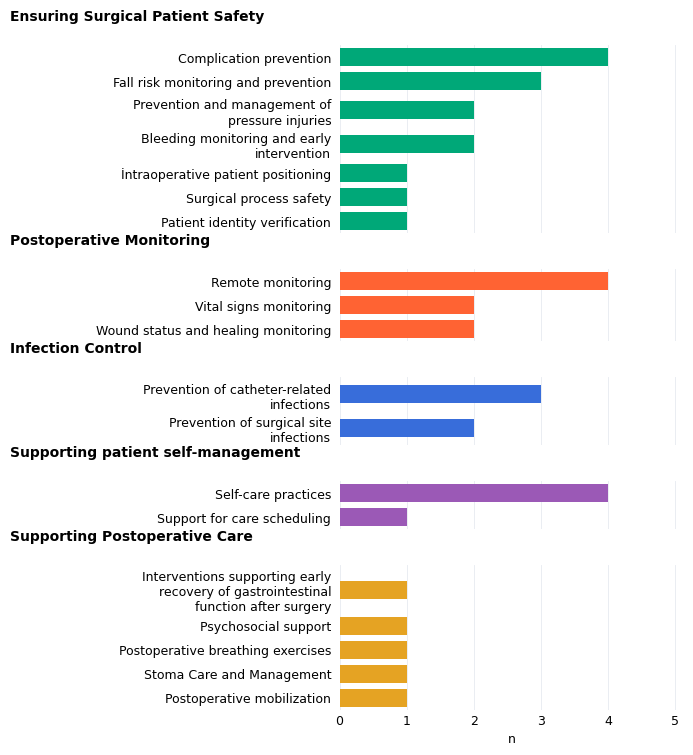

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import io
import textwrap
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def grafik_olustur(excel, cikti_klasoru='.'):
    df = pd.read_excel(excel, sheet_name=0)
    df.columns = df.columns.astype(str).str.strip()
    gerekli = {'from', 'to', 'n'}
    if not gerekli.issubset(df.columns):
        raise ValueError('Excel sütunları from, to ve n olmalıdır.')
    df = df.dropna(how='all').copy()
    for sutun in ['from', 'to']:
        if df[sutun].isna().any():
            raise ValueError(f'{sutun} sütununda boş hücre var.')
        df[sutun] = df[sutun].astype(str).str.strip()
        if df[sutun].eq('').any():
            raise ValueError(f'{sutun} sütununda boş isim var.')
    df['n'] = pd.to_numeric(df['n'], errors='raise')
    if df.empty or df['n'].isna().any() or not df['n'].map(lambda x: 0 <= x < float('inf')).all():
        raise ValueError('n sütunu boş olmayan, sonlu ve negatif olmayan sayılar içermelidir.')

    # Ekran görüntüsündeki ilk üç grubun sırası.
    # Bir grup yeniden adlandırılırsa aşağıdaki listeyi de değiştirebilirsin.
    oncelik = ['Ensuring Surgical Patient Safety',
               'Postoperative Monitoring', 'Infection Control']
    mevcut = df['from'].drop_duplicates().tolist()
    gruplar = [g for g in oncelik if g in mevcut]
    gruplar += [g for g in mevcut if g not in gruplar]
    renkler = ['#00A878', '#FF6333', '#386DDA', '#9B59B6',
               '#E5A323', '#269DA8', '#D65A86']
    veriler = []
    for grup in gruplar:
        # Eşit sayılarda Excel'deki sıra korunur; satırlar birleştirilmez.
        veri = df.loc[df['from'].eq(grup)].sort_values('n', ascending=False, kind='stable').copy()
        veri['etiket'] = veri['to'].map(lambda s: textwrap.fill(s, width=36, break_long_words=False))
        veriler.append(veri)
    # Fiziksel baskı ölçüleri: 18 cm genişlik, 9 punto etiketler.
    # Her satırın yüksekliği metnin satır sayısına göre belirlenir.
    satir_yukseklikleri = [[max(.24, (s.count('\n') + 1) * .145 + .05)
                           for s in v['etiket']] for v in veriler]
    yukseklikler = [sum(h) for h in satir_yukseklikleri]
    grup_boslugu = .36
    toplam_yukseklik = sum(yukseklikler) + len(gruplar) * grup_boslugu + .42
    plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9,
                         'pdf.fonttype': 42, 'ps.fonttype': 42})
    fig = plt.figure(figsize=(18 / 2.54, toplam_yukseklik))
    axes = []
    ust = toplam_yukseklik - .08
    maksimum = max(float(df['n'].max()), 1)
    for i, (grup, veri) in enumerate(zip(gruplar, veriler)):
        fig.text(.025, ust / toplam_yukseklik, grup, ha='left', va='top',
                 fontsize=10, fontweight='bold')
        ust -= grup_boslugu
        alt = ust - yukseklikler[i]
        ax = fig.add_axes([.49, alt / toplam_yukseklik, .485,
                           yukseklikler[i] / toplam_yukseklik])
        axes.append(ax)
        konumlar, y = [], 0
        for h in satir_yukseklikleri[i]:
            konumlar.append(y + h / 2)
            y += h
        ax.barh(konumlar, veri['n'], height=.18, color=renkler[i % len(renkler)])
        ax.set_yticks(konumlar, veri['etiket'])
        ax.set_ylim(y, 0)
        ax.set_xlim(0, maksimum * 1.28)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_axisbelow(True)
        ax.grid(axis='x', color='#E6EAF0', linewidth=.6)
        ax.tick_params(axis='both', length=0)
        ax.tick_params(axis='y', pad=6)
        ax.tick_params(axis='x', labelbottom=(i == len(gruplar) - 1))
        for spine in ax.spines.values():
            spine.set_visible(False)
        ust = alt
    axes[-1].set_xlabel('n', labelpad=3)
    klasor = Path(cikti_klasoru)
    klasor.mkdir(parents=True, exist_ok=True)
    dosyalar = []
    for uzanti in ['png', 'pdf']:
        dosya = klasor / f'tematik_grafik.{uzanti}'
        fig.savefig(dosya, dpi=600, facecolor='white')
        dosyalar.append(dosya)
    return fig, dosyalar


if __name__ == '__main__':
    from google.colab import files
    import zipfile
    print('İsimlerini düzenleyip kaydettiğin Excel dosyasını seç.')
    yuklenen = files.upload()
    adaylar = [isim for isim in yuklenen if isim.lower().endswith('.xlsx')]
    if len(adaylar) != 1:
        raise ValueError('Lütfen tek bir .xlsx dosyası yükle.')
    fig, dosyalar = grafik_olustur(io.BytesIO(yuklenen[adaylar[0]]))
    plt.show()
    with zipfile.ZipFile('tematik_grafik_ciktilar.zip', 'w') as arsiv:
        for dosya in dosyalar:
            arsiv.write(dosya, arcname=dosya.name)
    files.download('tematik_grafik_ciktilar.zip')


Patent_IPC2106.xlsx dosyanı yükle.


Saving Patent_IPC2106.xlsx to Patent_IPC2106 (2).xlsx

Tüm ağdaki TLS değerine göre seçilen 10 IPC kodu:


,Sira,IPC,TLS,Patent sayisi,Farkli baglantili kod sayisi,Secildi
0,1,A61B 5/00,22,13,21,True
1,2,A61M 1/00,8,4,8,True
2,3,G16H 10/60,8,3,8,True
3,4,G06T 7/00,7,2,6,True
4,5,G16H 20/30,7,2,7,True
5,6,A61B 5/103,6,2,6,True
6,7,A61B 5/11,5,1,5,True
7,8,G16H 40/67,5,1,5,True
8,9,G16H 50/00,5,1,5,True
9,10,G16H 80/00,5,1,5,True


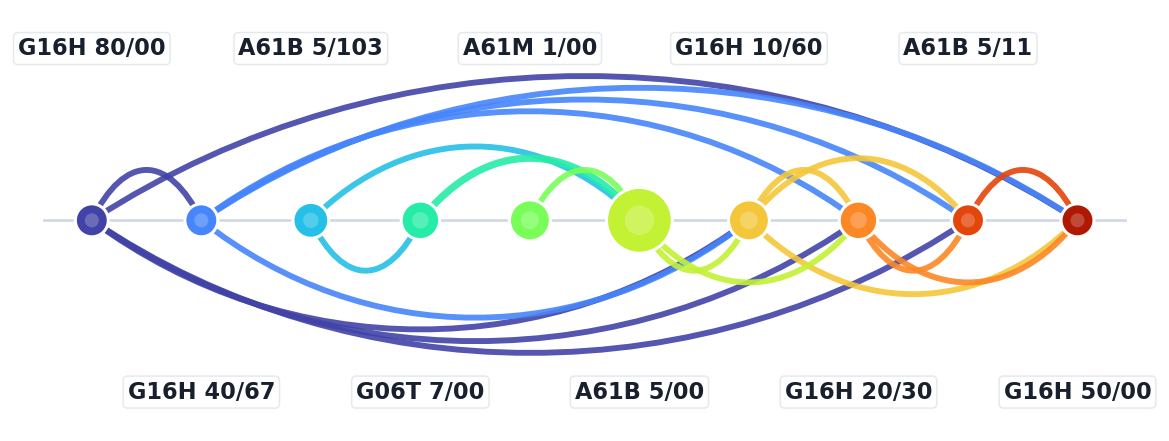

Toplam benzersiz patent: 32
Toplam IPC kodu: 59
TLS ile seçilen kod sayısı: 10
Grafikteki bağlantı sayısı: 21
Düğüm alanları TLS ile doğrudan orantılıdır.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install pandas openpyxl matplotlib

import io
import re
import zipfile
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from google.colab import files
from IPython.display import display


# =====================================================
# 1. AYARLAR
# =====================================================

KOD_SAYISI = 10

GENISLIK_CM = 18
YUKSEKLIK_CM = 6.5
YAZI_BOYUTU = 9
DPI = 600

# Yaylar önceki sürüme göre biraz kalınlaştırıldı.
# Birim: punto
MIN_YAY_KALINLIGI = 1.8
EK_YAY_KALINLIGI = 1.1

# Düğüm alanları TLS ile doğrudan orantılıdır.
# En büyük düğümün alanı: punto kare
MAKSIMUM_DUGUM_ALANI = 630

CIKTI_ADI = f"ipc_TLS_top{KOD_SAYISI}"


# =====================================================
# 2. EXCEL DOSYASINI YÜKLE
# =====================================================

print("Patent_IPC2106.xlsx dosyanı yükle.")
uploaded = files.upload()

excel_dosyalari = [
    isim for isim in uploaded
    if isim.lower().endswith(".xlsx")
]

if len(excel_dosyalari) != 1:
    raise ValueError("Lütfen tek bir .xlsx dosyası yükle.")

df = pd.read_excel(
    io.BytesIO(uploaded[excel_dosyalari[0]])
)

df.columns = df.columns.astype(str).str.strip()
df = df.dropna(how="all")

if not {"Patent ID", "IPC"}.issubset(df.columns):
    raise ValueError(
        "Excel dosyasında 'Patent ID' ve 'IPC' sütunları olmalı."
    )

if df.empty:
    raise ValueError("Excel dosyasında veri bulunamadı.")

if df[["Patent ID", "IPC"]].isna().any().any():
    raise ValueError("Patent ID veya IPC sütununda boş hücre var.")


# =====================================================
# 3. PATENTLERİN BENZERSİZ IPC KODLARINI HAZIRLA
# =====================================================

patentler = defaultdict(set)

for patent_id, ipc_hucresi in zip(df["Patent ID"], df["IPC"]):

    patent_id = str(patent_id).strip()

    if not patent_id:
        raise ValueError("Boş Patent ID bulundu.")

    kodlar = set()

    for ham_kod in str(ipc_hucresi).split(";"):

        kod = re.sub(r"\s+", "", ham_kod).upper()

        if not kod:
            continue

        # Örnek: A61G13/12 → A61G 13/12
        kod = re.sub(
            r"^([A-HY]\d{2}[A-Z])",
            r"\1 ",
            kod
        )

        kodlar.add(kod)

    if not kodlar:
        raise ValueError(
            f"{patent_id} için IPC kodu bulunamadı."
        )

    # Aynı patent tekrar ederse kodları birleştirilir.
    # Bir IPC kodu aynı patentte yalnızca bir kez sayılır.
    patentler[patent_id].update(kodlar)


# =====================================================
# 4. TÜM AĞDA BAĞLANTI AĞIRLIKLARINI HESAPLA
# =====================================================

patent_sayilari = Counter()
baglantilar = Counter()

for kodlar in patentler.values():

    patent_sayilari.update(kodlar)

    # Tam sayım:
    # Aynı patentte birlikte bulunan her benzersiz IPC çifti
    # bağlantı ağırlığına 1 katkı yapar.
    baglantilar.update(
        combinations(sorted(kodlar), 2)
    )


# =====================================================
# 5. TÜM AĞ ÜZERİNDEN TLS HESAPLA
# =====================================================

# TLS = Bir kodun diğer bütün kodlarla bağlantı
# ağırlıklarının toplamı.
tls = Counter({
    kod: 0 for kod in patent_sayilari
})

farkli_komsu_sayilari = Counter()

for (kod1, kod2), agirlik in baglantilar.items():

    tls[kod1] += agirlik
    tls[kod2] += agirlik

    farkli_komsu_sayilari[kod1] += 1
    farkli_komsu_sayilari[kod2] += 1

# Her bağlantı iki uçtaki TLS değerine katkı yapar.
assert sum(tls.values()) == 2 * sum(baglantilar.values())

if not baglantilar:
    raise ValueError(
        "IPC kodları arasında ortak bulunma bağlantısı yok."
    )


# =====================================================
# 6. TLS'Sİ EN YÜKSEK 10 KODU OTOMATİK SEÇ
# =====================================================

# TLS eşitliğinde alfabetik sıra kullanılır.
sirali_kodlar = sorted(
    tls,
    key=lambda kod: (-tls[kod], kod)
)

if len(sirali_kodlar) < KOD_SAYISI:
    raise ValueError(
        f"Dosyada {KOD_SAYISI} farklı IPC kodu bulunmuyor."
    )

secili_kodlar = sirali_kodlar[:KOD_SAYISI]

if tls[secili_kodlar[-1]] <= 0:
    raise ValueError(
        f"Pozitif TLS değerine sahip {KOD_SAYISI} kod bulunmuyor."
    )

esik_tls = tls[secili_kodlar[-1]]

if (
    len(sirali_kodlar) > KOD_SAYISI
    and tls[sirali_kodlar[KOD_SAYISI]] == esik_tls
):
    esikteki_kodlar = [
        kod for kod in sirali_kodlar
        if tls[kod] == esik_tls
    ]

    print(
        f"Seçim sınırında TLS={esik_tls} eşitliği var. "
        f"Tam {KOD_SAYISI} kod seçmek için "
        "eşitlik alfabetik sırayla çözüldü."
    )

    print(
        "Eşit TLS değerindeki kodlar:",
        ", ".join(esikteki_kodlar)
    )

tum_tablo = pd.DataFrame({
    "Sira": range(1, len(sirali_kodlar) + 1),
    "IPC": sirali_kodlar,
    "TLS": [
        tls[kod] for kod in sirali_kodlar
    ],
    "Patent sayisi": [
        patent_sayilari[kod] for kod in sirali_kodlar
    ],
    "Farkli baglantili kod sayisi": [
        farkli_komsu_sayilari[kod]
        for kod in sirali_kodlar
    ],
    "Secildi": [
        kod in secili_kodlar
        for kod in sirali_kodlar
    ],
})

print(
    f"\nTüm ağdaki TLS değerine göre seçilen "
    f"{KOD_SAYISI} IPC kodu:"
)

display(tum_tablo.head(KOD_SAYISI))


# =====================================================
# 7. GRAFİKTEKİ DÜĞÜM SIRASINI HAZIRLA
# =====================================================

# En yüksek TLS'li kodlar merkeze yakın yerleştirilir.
# Bu işlem seçimi veya TLS değerlerini değiştirmez.
dugumler = []

for i, kod in enumerate(secili_kodlar):
    if i % 2 == 0:
        dugumler.append(kod)
    else:
        dugumler.insert(0, kod)

konum = {
    kod: i for i, kod in enumerate(dugumler)
}

# Grafikte yalnızca seçilen kodlar arasındaki bağlantılar.
gosterilen_baglantilar = []

for (kod1, kod2), agirlik in baglantilar.items():

    if kod1 in konum and kod2 in konum:

        a, b = sorted([
            konum[kod1],
            konum[kod2]
        ])

        gosterilen_baglantilar.append(
            (a, b, agirlik)
        )

# Uzun yaylar önce çizilir.
gosterilen_baglantilar.sort(
    key=lambda x: (
        -(x[1] - x[0]),
        x[0],
        x[1]
    )
)


# =====================================================
# 8. GRAFİĞİ OLUŞTUR
# =====================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": YAZI_BOYUTU,
    "figure.dpi": 180,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "path",
})

n = len(dugumler)

renkler = plt.get_cmap("turbo")(
    np.linspace(0.07, 0.93, n)
)

fig, ax = plt.subplots(
    figsize=(
        GENISLIK_CM / 2.54,
        YUKSEKLIK_CM / 2.54
    )
)

fig.subplots_adjust(
    left=0.075,
    right=0.925,
    bottom=0.06,
    top=0.94
)

ax.axhline(
    0,
    color="#CDD7E5",
    linewidth=1,
    zorder=0
)

maksimum_agirlik = max(
    (
        agirlik
        for _, _, agirlik in gosterilen_baglantilar
    ),
    default=1
)

# Bağlantı yayları
for sira, (a, b, agirlik) in enumerate(
    gosterilen_baglantilar
):

    uzaklik = b - a
    yon = 1 if sira % 2 == 0 else -1

    yukseklik = yon * (
        0.30 + 0.82 * uzaklik / (n - 1)
    )

    yay = Path(
        [
            (a, 0),
            (a + 0.30 * uzaklik, yukseklik),
            (b - 0.30 * uzaklik, yukseklik),
            (b, 0),
        ],
        [
            Path.MOVETO,
            Path.CURVE4,
            Path.CURVE4,
            Path.CURVE4,
        ]
    )

    yay_kalinligi = (
        MIN_YAY_KALINLIGI
        + EK_YAY_KALINLIGI
        * agirlik / maksimum_agirlik
    )

    ax.add_patch(
        PathPatch(
            yay,
            facecolor="none",
            edgecolor=renkler[a],
            linewidth=yay_kalinligi,
            alpha=0.90,
            capstyle="round",
            zorder=1,
        )
    )


# =====================================================
# 9. DÜĞÜM ALANLARINI TLS İLE DOĞRUDAN ÖLÇEKLE
# =====================================================

tls_degerleri = np.array(
    [tls[kod] for kod in dugumler],
    dtype=float
)

# Sabit minimum alan eklenmez.
# TLS iki katına çıktığında düğüm alanı da iki katına çıkar.
dugum_alanlari = (
    MAKSIMUM_DUGUM_ALANI
    * tls_degerleri / tls_degerleri.max()
)

# Beyaz dış halka
ax.scatter(
    range(n),
    np.zeros(n),
    s=(np.sqrt(dugum_alanlari) + 2.4) ** 2,
    color="white",
    linewidths=0,
    zorder=2,
)

# Renkli düğüm alanları TLS ile doğrudan orantılıdır.
ax.scatter(
    range(n),
    np.zeros(n),
    s=dugum_alanlari,
    c=renkler,
    linewidths=0,
    zorder=3,
)

# İç vurgu
ax.scatter(
    range(n),
    np.zeros(n),
    s=dugum_alanlari * 0.22,
    color="white",
    alpha=0.22,
    linewidths=0,
    zorder=4,
)

# IPC etiketleri
for i, kod in enumerate(dugumler):

    ax.text(
        i,
        1.00 if i % 2 == 0 else -1.00,
        kod,
        ha="center",
        va="center",
        fontsize=YAZI_BOYUTU,
        fontweight="bold",
        color="#18202D",
        clip_on=False,
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "#E5E8EE",
            "linewidth": 0.6,
        },
        zorder=5,
    )

ax.set_xlim(-0.45, n - 0.55)
ax.set_ylim(-1.18, 1.18)
ax.axis("off")


# =====================================================
# 10. PNG, PDF VE SVG OLARAK KAYDET
# =====================================================

ciktilar = []

for uzanti in ["png", "pdf", "svg"]:

    dosya_adi = f"{CIKTI_ADI}.{uzanti}"

    fig.savefig(
        dosya_adi,
        dpi=DPI,
        facecolor="white"
    )

    ciktilar.append(dosya_adi)

plt.show()


# =====================================================
# 11. HESAPLAMA TABLOLARINI KAYDET
# =====================================================

tum_tablo.to_csv(
    "tum_IPC_TLS_siralamasi.csv",
    index=False,
    encoding="utf-8-sig"
)

secili_tablo_adi = f"secilen_{KOD_SAYISI}_IPC.csv"

tum_tablo.head(KOD_SAYISI).to_csv(
    secili_tablo_adi,
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(
    [
        (kod1, kod2, agirlik)
        for (kod1, kod2), agirlik
        in sorted(baglantilar.items())
    ],
    columns=[
        "Source",
        "Target",
        "Link strength"
    ]
).to_csv(
    "tum_ag_baglantilari.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame(
    [
        (dugumler[a], dugumler[b], agirlik)
        for a, b, agirlik in gosterilen_baglantilar
    ],
    columns=[
        "Source",
        "Target",
        "Link strength"
    ]
).to_csv(
    "grafikteki_baglantilar.csv",
    index=False,
    encoding="utf-8-sig"
)

ciktilar += [
    "tum_IPC_TLS_siralamasi.csv",
    secili_tablo_adi,
    "tum_ag_baglantilari.csv",
    "grafikteki_baglantilar.csv",
]


# =====================================================
# 12. YÖNTEM BİLGİSİNİ KAYDET
# =====================================================

yontem = f"""IPC ortak bulunma ağı

Benzersiz patent sayısı: {len(patentler)}
Toplam IPC kodu sayısı: {len(sirali_kodlar)}
Seçilen IPC kodu sayısı: {KOD_SAYISI}

Sayım yöntemi: Tam sayım.
Aynı patentte birlikte bulunan her benzersiz IPC çifti,
bağlantı ağırlığına 1 katkı yapar.
Aynı IPC kodu bir patent içinde tekrar sayılmaz.

TLS, bir IPC kodunun tüm ağdaki diğer kodlarla bağlantı
ağırlıklarının toplamıdır.

TLS değeri en yüksek {KOD_SAYISI} IPC kodu otomatik seçilmiştir.
TLS eşitliğinde alfabetik sıra kullanılmıştır.

Grafikte yalnızca seçilen kodlar arasındaki bağlantılar
gösterilmiştir. TLS değerleri bu alt ağda yeniden hesaplanmamıştır.

Renkli düğüm alanları tüm ağdaki TLS ile doğrudan orantılıdır:
Alan = {MAKSIMUM_DUGUM_ALANI} × TLS / seçilen en yüksek TLS.
Alan birimi punto karedir. Sabit minimum alan eklenmemiştir.

Yay kalınlığı bağlantı ağırlığıyla artar.
Renkler kodları ayırt etmek içindir; küme analizi sonucu değildir.
Yayların üst/alt konumu yalnızca görsel yerleşimdir.
"""

with open(
    "yontem_bilgisi.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(yontem)

ciktilar.append("yontem_bilgisi.txt")

print(f"Toplam benzersiz patent: {len(patentler)}")
print(f"Toplam IPC kodu: {len(sirali_kodlar)}")
print(f"TLS ile seçilen kod sayısı: {len(secili_kodlar)}")
print(f"Grafikteki bağlantı sayısı: {len(gosterilen_baglantilar)}")
print("Düğüm alanları TLS ile doğrudan orantılıdır.")


# =====================================================
# 13. TÜM ÇIKTILARI ZIP OLARAK İNDİR
# =====================================================

zip_adi = f"{CIKTI_ADI}_ciktilar.zip"

with zipfile.ZipFile(
    zip_adi,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as arsiv:

    for dosya_adi in ciktilar:
        arsiv.write(dosya_adi)

files.download(zip_adi)

Patent_ID2106.xlsx ve Patient-Citation_2106.xlsx dosyalarını birlikte seç.


Saving Patient-Citation_2106.xlsx to Patient-Citation_2106.xlsx
Saving Patent_ID2106.xlsx to Patent_ID2106.xlsx
Liste içi patentlerin atıf analizi:


,Patent ID,Alinan atif,Verilen atif,Toplam yonlu baglanti,Secildi
0,TR201909670A2,1,0,1,True
1,TR2021019692A2,0,5,5,True
2,TR201913355A2,0,4,4,True
3,TR202015535A1,0,4,4,True
4,TR2021019643A2,0,4,4,True
5,TR2022008605A2,0,4,4,True
6,TR2021020681A1,0,3,3,True
7,TR2022018456A1,0,3,3,True
8,TR201901137A2,0,0,0,False
9,TR202009666A2,0,0,0,False



Merkez patent: TR201909670A2
Merkezin aldığı atıf: 1
Seçilen liste içi patent: 8
Bağlantısız olduğu için dışlanan patent: 24
Gösterilen bağlantı: 28


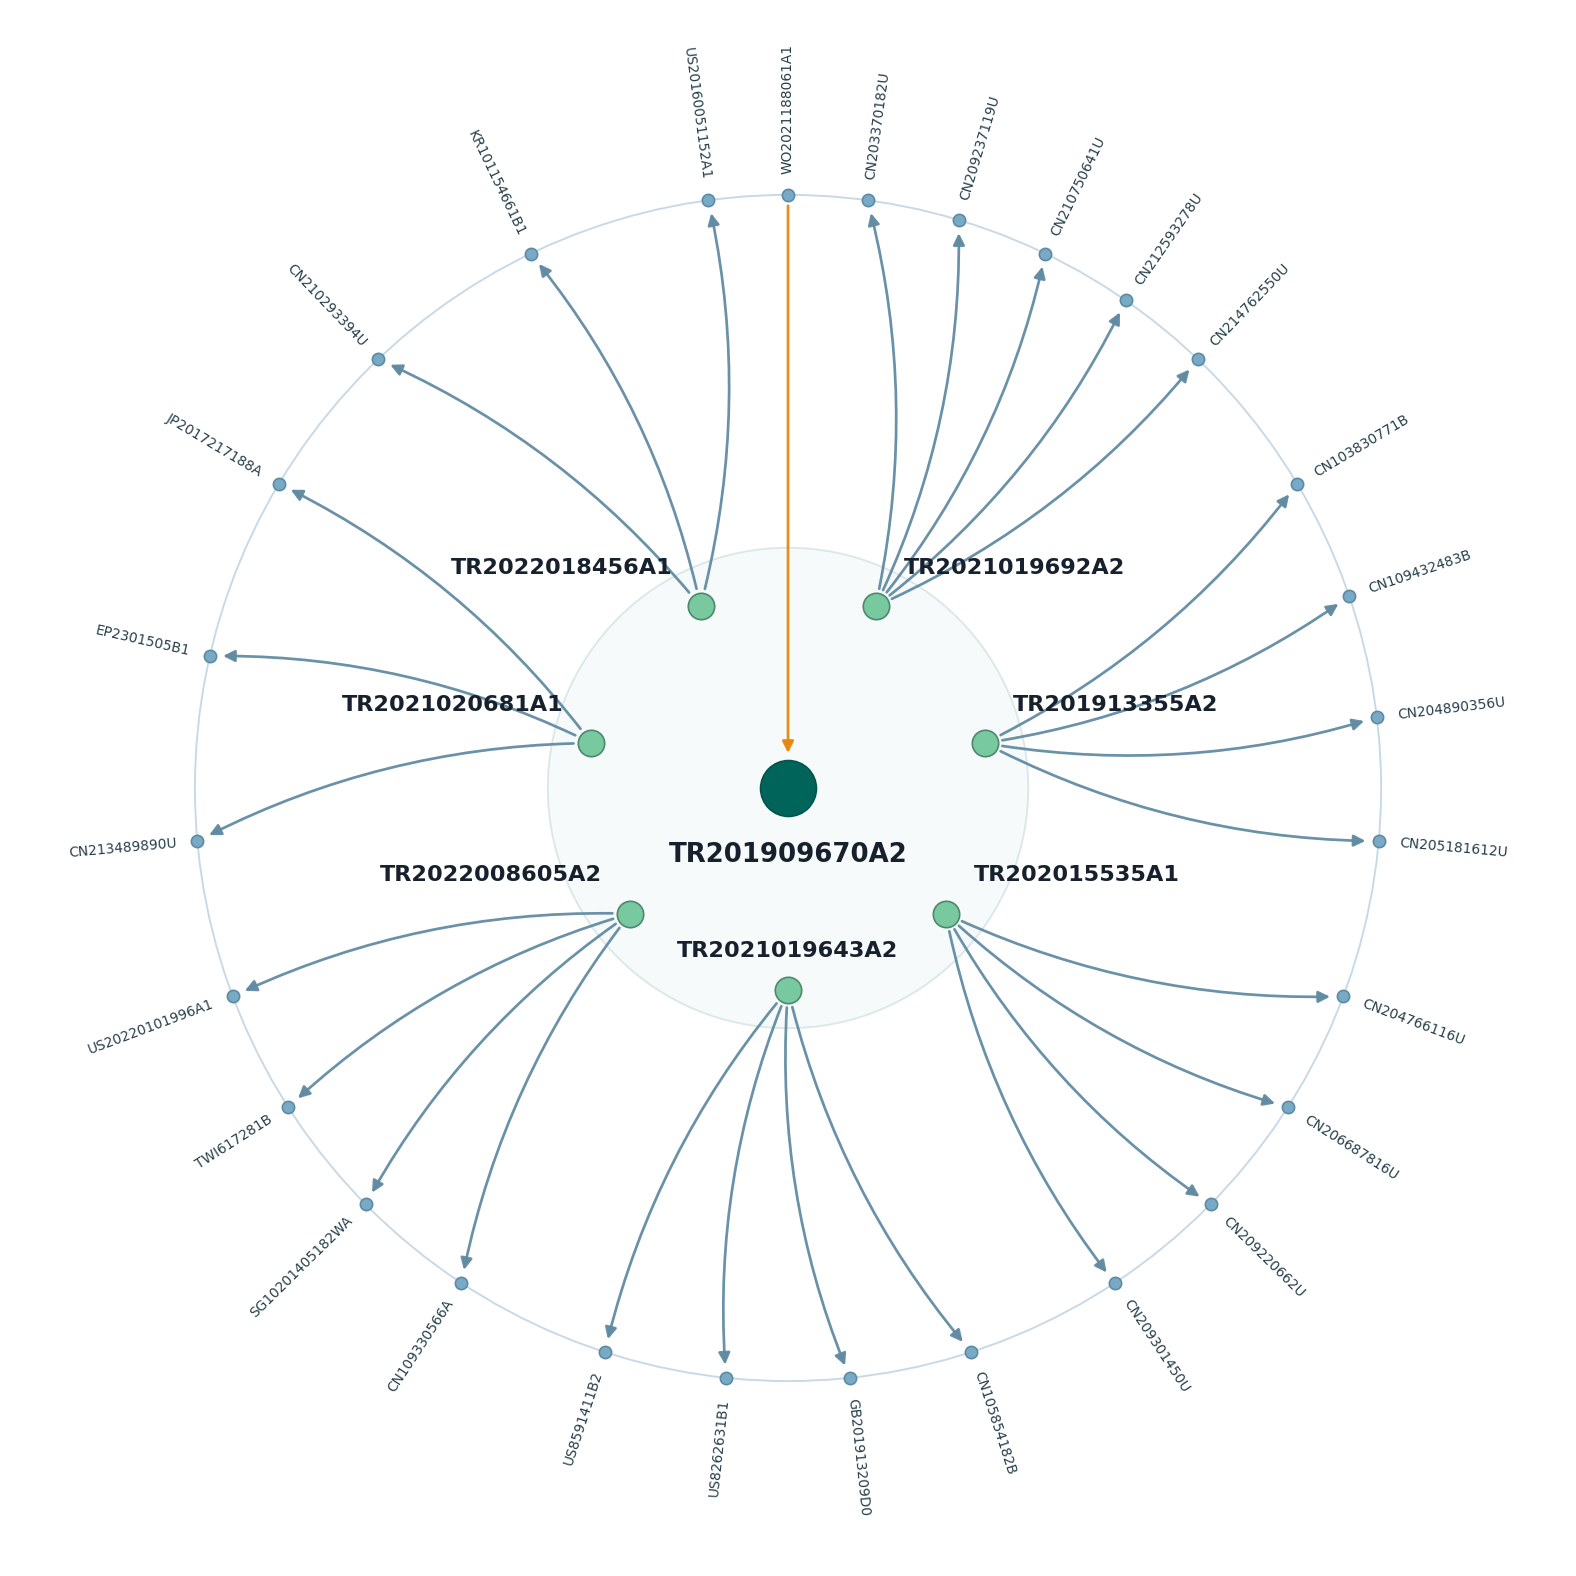

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip -q install pandas openpyxl numpy matplotlib

import io
import json
import hashlib
import platform
import zipfile
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
from google.colab import files
from IPython.display import display


# =====================================================
# 1. AYARLAR
# =====================================================

DPI = 600
FIGUR_BOYUTU_CM = 24

IC_YARICAP = 0.34
DIS_YARICAP = 1.0

IC_DUGUM_BOYUTU = 125
DIS_DUGUM_BOYUTU = 27
MERKEZ_DUGUM_BOYUTU = 560

# Yalnızca içteki patent yazıları belirginleştirildi.
IC_YAZI_BOYUTU = 9.5
IC_YAZI_KALINLIGI = "heavy"

MERKEZ_YAZI_BOYUTU = 11
MERKEZ_YAZI_KALINLIGI = "heavy"

# Dış yazılar aynı bırakıldı.
DIS_YAZI_BOYUTU = 5.8

OK_KALINLIGI = 1.15
OK_UCU_BOYUTU = 10

IC_RENK = "#78C99F"
DIS_RENK = "#78A9C5"
MERKEZ_RENK = "#00645B"
OK_RENK = "#618BA3"
TURUNCU = "#E8870B"

CIKTI_ADI = "patent_atif_agi"


# =====================================================
# 2. DOSYALARI YÜKLE
# =====================================================

print(
    "Patent_ID2106.xlsx ve Patient-Citation_2106.xlsx "
    "dosyalarını birlikte seç."
)

uploaded = files.upload()

id_df = None
edge_df = None
kaynak_bilgisi = {}

for isim, icerik in uploaded.items():

    if not isim.lower().endswith(".xlsx"):
        continue

    tablo = pd.read_excel(io.BytesIO(icerik))
    tablo.columns = tablo.columns.astype(str).str.strip()

    if {"Source Patent", "Target Patent"}.issubset(tablo.columns):

        if edge_df is not None:
            raise ValueError("Birden fazla bağlantı dosyası yüklendi.")

        edge_df = tablo

        kaynak_bilgisi["baglantilar"] = {
            "dosya": isim,
            "sha256": hashlib.sha256(icerik).hexdigest()
        }

    elif "Patent ID" in tablo.columns:

        if id_df is not None:
            raise ValueError("Birden fazla Patent ID dosyası yüklendi.")

        id_df = tablo

        kaynak_bilgisi["patent_listesi"] = {
            "dosya": isim,
            "sha256": hashlib.sha256(icerik).hexdigest()
        }

if id_df is None or edge_df is None:
    raise ValueError(
        "'Patent ID' sütunlu dosya ile 'Source Patent' ve "
        "'Target Patent' sütunlu dosyayı birlikte yükle."
    )


# =====================================================
# 3. VERİ KONTROLÜ
# =====================================================

id_df = id_df[["Patent ID"]].dropna(how="all").copy()

edge_df = (
    edge_df[["Source Patent", "Target Patent"]]
    .dropna(how="all")
    .copy()
)

if id_df.empty or edge_df.empty:
    raise ValueError("Dosyalardan biri boş.")

if id_df.isna().any().any() or edge_df.isna().any().any():
    raise ValueError("Gerekli sütunlarda boş hücre var.")

id_df["Patent ID"] = id_df["Patent ID"].astype(str).str.strip()

for sutun in edge_df.columns:
    edge_df[sutun] = edge_df[sutun].astype(str).str.strip()

if id_df.eq("").any().any() or edge_df.eq("").any().any():
    raise ValueError("Boş patent numarası bulundu.")

ham_satir_sayisi = len(edge_df)

# Aynı kaynak-hedef çifti bir kez sayılır.
edge_df = (
    edge_df.drop_duplicates()
    .sort_values(["Source Patent", "Target Patent"])
    .reset_index(drop=True)
)

if (
    edge_df["Source Patent"] == edge_df["Target Patent"]
).any():
    raise ValueError(
        "Kendisine atıf yapan patent satırı bulundu. "
        "Kaynak veriyi kontrol et."
    )

patent_ids = set(id_df["Patent ID"])
edges = list(edge_df.itertuples(index=False, name=None))


# =====================================================
# 4. GELEN VE GİDEN ATIFLARI HESAPLA
# =====================================================

# Source = atıf yapan, Target = atıf alan.
giden = Counter(kaynak for kaynak, hedef in edges)
gelen = Counter(hedef for kaynak, hedef in edges)

analiz = pd.DataFrame([
    {
        "Patent ID": patent,
        "Alinan atif": gelen[patent],
        "Verilen atif": giden[patent],
        "Toplam yonlu baglanti": gelen[patent] + giden[patent],
        "Secildi": gelen[patent] + giden[patent] > 0
    }
    for patent in sorted(patent_ids)
])

analiz = analiz.sort_values(
    ["Alinan atif", "Verilen atif", "Patent ID"],
    ascending=[False, False, True]
).reset_index(drop=True)

# En az bir atıf alan veya veren liste içi patentler.
secili_ic = {
    patent for patent in patent_ids
    if gelen[patent] + giden[patent] > 0
}

dislanan = patent_ids - secili_ic

if not secili_ic:
    raise ValueError("Atıf bağlantısı bulunan liste içi patent yok.")

# En fazla atıf alan liste içi patent merkezde.
merkez = sorted(
    secili_ic,
    key=lambda p: (-gelen[p], -giden[p], p)
)[0]

gosterilen_edges = [
    (kaynak, hedef)
    for kaynak, hedef in edges
    if kaynak in secili_ic or hedef in secili_ic
]

gosterilen_dugumler = {
    patent
    for baglanti in gosterilen_edges
    for patent in baglanti
}

dis_dugumler = gosterilen_dugumler - secili_ic

ic_halka = sorted(
    secili_ic - {merkez},
    key=lambda p: (-giden[p], -gelen[p], p)
)

print("Liste içi patentlerin atıf analizi:")
display(analiz)

print(f"\nMerkez patent: {merkez}")
print(f"Merkezin aldığı atıf: {gelen[merkez]}")
print(f"Seçilen liste içi patent: {len(secili_ic)}")
print(f"Bağlantısız olduğu için dışlanan patent: {len(dislanan)}")
print(f"Gösterilen bağlantı: {len(gosterilen_edges)}")


# =====================================================
# 5. DIŞ PATENTLERİ GRUPLA
# =====================================================

gruplar = defaultdict(list)

merkeze_atif_yapanlar = {
    kaynak
    for kaynak, hedef in gosterilen_edges
    if hedef == merkez and kaynak in dis_dugumler
}

ic_sira = {p: i for i, p in enumerate(ic_halka)}

for dis_patent in sorted(dis_dugumler):

    if dis_patent in merkeze_atif_yapanlar:
        gruplar[merkez].append(dis_patent)
        continue

    komsular = {
        hedef if kaynak == dis_patent else kaynak
        for kaynak, hedef in gosterilen_edges
        if kaynak == dis_patent or hedef == dis_patent
    } & secili_ic

    halka_komsulari = komsular - {merkez}

    if halka_komsulari:
        sahip = min(
            halka_komsulari,
            key=lambda p: ic_sira[p]
        )
    else:
        sahip = merkez

    gruplar[sahip].append(dis_patent)


# =====================================================
# 6. DAİRESEL KONUMLAR — BEĞENDİĞİN DÜZEN KORUNDU
# =====================================================

konum = {merkez: np.array([0.0, 0.0])}
dis_acilar = {}
ic_acilar = {}

halka_sayisi = len(ic_halka)

if halka_sayisi:

    sektor = 360 / halka_sayisi

    for i, patent in enumerate(ic_halka):

        derece = 90 - sektor / 2 - i * sektor
        ic_acilar[patent] = derece

        theta = np.radians(derece)

        konum[patent] = IC_YARICAP * np.array([
            np.cos(theta),
            np.sin(theta)
        ])

        dis_liste = sorted(gruplar[patent])
        adet = len(dis_liste)

        if adet == 1:
            acilar = [derece]

        elif adet > 1:
            acilar = np.linspace(
                derece + sektor * 0.35,
                derece - sektor * 0.35,
                adet
            )

        else:
            acilar = []

        for dis_patent, dis_aci in zip(dis_liste, acilar):
            dis_acilar[dis_patent] = float(dis_aci)

merkez_dis_liste = sorted(gruplar[merkez])

if len(merkez_dis_liste) == 1:
    ust_acilar = [90.0]

elif len(merkez_dis_liste) > 1:
    aciklik = min(
        20,
        (360 / max(halka_sayisi, 1)) * 0.30
    )

    ust_acilar = np.linspace(
        90 + aciklik / 2,
        90 - aciklik / 2,
        len(merkez_dis_liste)
    )

else:
    ust_acilar = []

for patent, derece in zip(merkez_dis_liste, ust_acilar):
    dis_acilar[patent] = float(derece)

for patent, derece in dis_acilar.items():

    theta = np.radians(derece)

    konum[patent] = DIS_YARICAP * np.array([
        np.cos(theta),
        np.sin(theta)
    ])

if set(konum) != gosterilen_dugumler:
    raise ValueError("Bazı düğümlerin konumu oluşturulamadı.")


# =====================================================
# 7. ŞEKLİ HAZIRLA
# =====================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 170,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "path"
})

fig, ax = plt.subplots(
    figsize=(
        FIGUR_BOYUTU_CM / 2.54,
        FIGUR_BOYUTU_CM / 2.54
    )
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.02,
    top=0.98
)

ax.set_aspect("equal")
ax.axis("off")

ax.add_patch(Circle(
    (0, 0),
    DIS_YARICAP,
    fill=False,
    edgecolor="#C7D9E7",
    linewidth=0.8,
    zorder=0
))

ax.add_patch(Circle(
    (0, 0),
    IC_YARICAP + 0.065,
    facecolor="#F7FAFA",
    edgecolor="#DCE8E8",
    linewidth=0.8,
    zorder=0
))


# =====================================================
# 8. OKLAR — AYNI BIRAKILDI
# =====================================================

def dugum_boyutu(patent):
    if patent == merkez:
        return MERKEZ_DUGUM_BOYUTU
    if patent in secili_ic:
        return IC_DUGUM_BOYUTU
    return DIS_DUGUM_BOYUTU


for kaynak, hedef in gosterilen_edges:

    turuncu = (
        hedef == merkez
        and kaynak in dis_dugumler
    )

    ax.add_patch(FancyArrowPatch(
        posA=konum[kaynak],
        posB=konum[hedef],
        arrowstyle="-|>",
        connectionstyle=(
            "arc3,rad=0" if turuncu else "arc3,rad=0.12"
        ),
        mutation_scale=OK_UCU_BOYUTU,
        linewidth=OK_KALINLIGI,
        color=TURUNCU if turuncu else OK_RENK,
        alpha=0.95,
        shrinkA=np.sqrt(dugum_boyutu(kaynak)) / 2 + 2,
        shrinkB=np.sqrt(dugum_boyutu(hedef)) / 2 + 3,
        zorder=2 if turuncu else 1
    ))


# =====================================================
# 9. DÜĞÜMLER
# =====================================================

for patent in sorted(gosterilen_dugumler):

    if patent == merkez:
        renk, kenar = MERKEZ_RENK, "#00544C"

    elif patent in secili_ic:
        renk, kenar = IC_RENK, "#4D886D"

    else:
        renk, kenar = DIS_RENK, "#5D8BA5"

    ax.scatter(
        *konum[patent],
        s=dugum_boyutu(patent),
        color=renk,
        edgecolors=kenar,
        linewidths=0.7,
        zorder=3
    )


# =====================================================
# 10. İÇ PATENT YAZILARI
# Biraz yukarı taşındı ve kalınlaştırıldı.
# =====================================================

for patent in ic_halka:

    x, y = konum[patent]
    theta = np.radians(ic_acilar[patent])

    if abs(np.cos(theta)) < 0.18:
        # Alt/üst orta düğüm: yazı düğümün üstünde.
        dx = 0
        ha = "center"
    else:
        dx = 12 if x > 0 else -12
        ha = "left" if x > 0 else "right"

    ax.annotate(
        patent,
        xy=(x, y),
        xytext=(dx, 12),
        textcoords="offset points",
        ha=ha,
        va="bottom",
        fontsize=IC_YAZI_BOYUTU,
        fontweight=IC_YAZI_KALINLIGI,
        color="#17212D",
        zorder=6
    )

# Merkezdeki numaranın konumu korundu, kalınlaştırıldı.
ax.annotate(
    merkez,
    xy=konum[merkez],
    xytext=(0, -23),
    textcoords="offset points",
    ha="center",
    va="top",
    fontsize=MERKEZ_YAZI_BOYUTU,
    fontweight=MERKEZ_YAZI_KALINLIGI,
    color="#17212D",
    zorder=6
)


# =====================================================
# 11. DIŞ ETİKETLER — AYNI BIRAKILDI
# =====================================================

for patent, derece in dis_acilar.items():

    theta = np.radians(derece)
    aci_360 = derece % 360
    etiket_r = DIS_YARICAP + 0.035

    if 90 < aci_360 < 270:
        donus = derece + 180
        ha = "right"
    else:
        donus = derece
        ha = "left"

    ax.text(
        etiket_r * np.cos(theta),
        etiket_r * np.sin(theta),
        patent,
        rotation=donus,
        rotation_mode="anchor",
        ha=ha,
        va="center",
        fontsize=DIS_YAZI_BOYUTU,
        color="#263E4A",
        clip_on=False,
        zorder=5
    )

ax.set_xlim(-1.30, 1.30)
ax.set_ylim(-1.30, 1.30)


# =====================================================
# 12. GRAFİKLERİ VE TABLOLARI KAYDET
# =====================================================

ciktilar = []

for uzanti in ["png", "pdf", "svg"]:

    isim = f"{CIKTI_ADI}.{uzanti}"

    fig.savefig(
        isim,
        dpi=DPI,
        facecolor="white",
        bbox_inches="tight",
        pad_inches=0.20
    )

    ciktilar.append(isim)

plt.show()

analiz.to_csv(
    "liste_ici_atif_analizi.csv",
    index=False,
    encoding="utf-8-sig"
)
ciktilar.append("liste_ici_atif_analizi.csv")

analiz.loc[~analiz["Secildi"]].to_csv(
    "dislanan_baglantisiz_patentler.csv",
    index=False,
    encoding="utf-8-sig"
)
ciktilar.append("dislanan_baglantisiz_patentler.csv")

pd.DataFrame(
    gosterilen_edges,
    columns=["Source Patent", "Target Patent"]
).to_csv(
    "gosterilen_baglantilar.csv",
    index=False,
    encoding="utf-8-sig"
)
ciktilar.append("gosterilen_baglantilar.csv")

pd.DataFrame([
    {
        "Patent": p,
        "Grup": (
            "Merkez" if p == merkez
            else "Liste ici" if p in secili_ic
            else "Liste disi"
        ),
        "Alinan atif": gelen[p],
        "Verilen atif": giden[p],
        "X": float(konum[p][0]),
        "Y": float(konum[p][1])
    }
    for p in sorted(gosterilen_dugumler)
]).to_csv(
    "dugumler_ve_konumlar.csv",
    index=False,
    encoding="utf-8-sig"
)
ciktilar.append("dugumler_ve_konumlar.csv")


# =====================================================
# 13. YÖNTEM VE SÜRÜM BİLGİSİ
# =====================================================

yontem = f"""Patent atıf ağı

Atıf yönü:
Source Patent (atıf yapan) -> Target Patent (atıf alan).

Hesaplamalar yüklenen bağlantı tablosuyla sınırlıdır;
patentlerin küresel toplam atıf sayılarını temsil etmez.

Aynı kaynak-hedef çifti bir kez sayılmıştır.
Gelen atıf, patentin hedef olduğu benzersiz bağlantı sayısıdır.
Giden atıf, patentin kaynak olduğu benzersiz bağlantı sayısıdır.

Patent ID listesinden en az bir gelen veya giden bağlantısı
bulunan bütün patentler seçilmiştir.
Hem gelen hem giden bağlantı sayısı sıfır olanlar dışlanmıştır.
İlk N patent veya bir atıf eşiği uygulanmamıştır.

Seçilen liste içi patent sayısı: {len(secili_ic)}
Dışlanan bağlantısız patent sayısı: {len(dislanan)}
Gösterilen bağlantı sayısı: {len(gosterilen_edges)}

Merkez, en fazla gelen atıfa sahip liste içi patenttir.
Eşitlikte giden atıf sayısı, sonra alfabetik sıra kullanılır.
Merkez patent: {merkez}

İç halka sırası giden atıf, gelen atıf ve alfabetik sırayla belirlenir.
Açılar yalnızca görsel yerleşim içindir.
Dış patentler bağlantılı oldukları iç patentlere göre gruplanır.
Birden fazla iç komşu varsa yerleşim sırasındaki ilk komşu kullanılır.
Bütün ilgili bağlantılar yine çizilir.

Merkeze atıf yapan dış patentler üst boşluğa yerleştirilir.
Bu bağlantılar turuncu, diğer bağlantılar mavi gösterilir.

Düğüm boyutları kategoriktir; atıf sayısıyla ölçeklenmez.
Patent isimleri veya seçim listesi kodda sabitlenmemiştir.
"""

with open("yontem.txt", "w", encoding="utf-8") as f:
    f.write(yontem)

ciktilar.append("yontem.txt")

with open(
    "calisma_bilgisi.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        {
            "kaynaklar": kaynak_bilgisi,
            "python": platform.python_version(),
            "pandas": pd.__version__,
            "numpy": np.__version__,
            "matplotlib": matplotlib.__version__,
            "ham_baglanti_satiri": ham_satir_sayisi,
            "benzersiz_baglanti": len(edges),
            "merkez": merkez,
            "dpi": DPI,
            "ic_yazi_boyutu": IC_YAZI_BOYUTU,
            "ic_yazi_kalinligi": IC_YAZI_KALINLIGI
        },
        f,
        ensure_ascii=False,
        indent=2
    )

ciktilar.append("calisma_bilgisi.json")


# =====================================================
# 14. TÜM ÇIKTILARI İNDİR
# =====================================================

zip_adi = f"{CIKTI_ADI}_ciktilar.zip"

with zipfile.ZipFile(
    zip_adi,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as arsiv:

    for isim in ciktilar:
        arsiv.write(isim)

files.download(zip_adi)